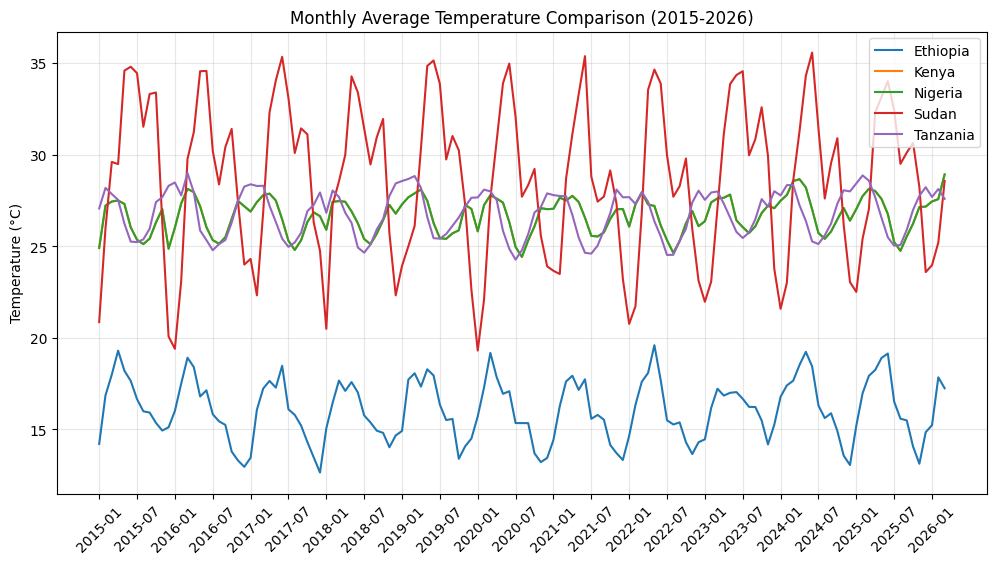

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")


ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])


if "Date" not in df.columns:
    df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
else:
    df["Date"] = pd.to_datetime(df["Date"])


df["Month_Period"] = df["Date"].dt.to_period("M")


monthly_temp = df.groupby(["Country", "Month_Period"])["T2M"].mean().reset_index()
monthly_temp["Month_Str"] = monthly_temp["Month_Period"].astype(str)


plt.figure(figsize=(12, 6))
for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month_Str"], subset["T2M"], label=country)


plt.xticks(monthly_temp["Month_Str"].unique()[::6], rotation=45)
plt.legend()
plt.title("Monthly Average Temperature Comparison (2015-2026)")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

### 🌍 Monthly Average Temperature Comparison (2015–2026)

- **Sudan** consistently records the highest temperatures (20–35 °C), highlighting its hotter climate profile.  
- **Ethiopia** shows the lowest averages (12–20 °C), reflecting cooler highland conditions.  
- **Kenya, Nigeria, and Tanzania** remain in a moderate band (24–29 °C), with seasonal fluctuations but less extreme variation.  

**Insight:** The graph underscores clear climatic contrasts—Sudan’s persistent heat vs. Ethiopia’s cooler range—while the other countries cluster in a stable mid-zone. This comparative view helps contextualize regional climate diversity across East and West Africa.


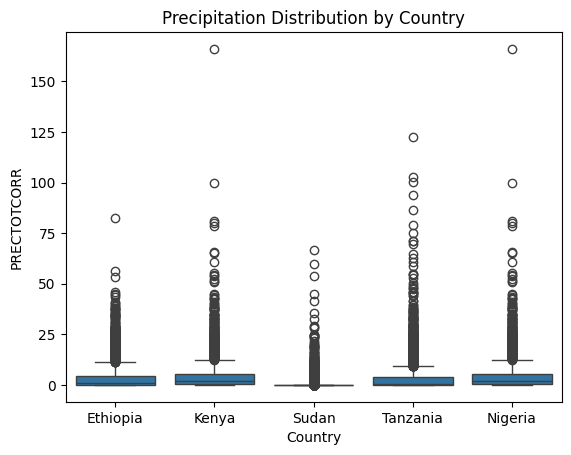

In [7]:
import seaborn as sns

sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Distribution by Country")
plt.show()

### 🌧️ Precipitation Distribution by Country
1. **Kenya & Nigeria** show wide spreads, indicating rainfall variability.  
2. **Ethiopia & Tanzania** have moderate distributions but frequent outliers, suggesting occasional extremes.  
3. **Sudan** has the lowest median precipitation, highlighting arid conditions.  
4. Outliers across all countries emphasize irregular heavy rainfall events.

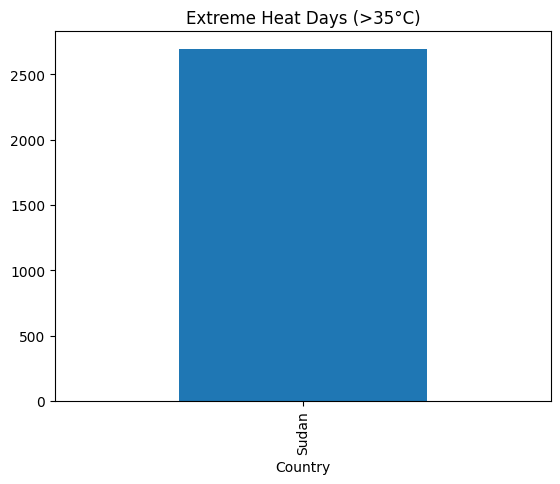

In [8]:
heat = df[df["T2M_MAX"] > 35]
heat_counts = heat.groupby("Country").size()

heat_counts.plot(kind="bar")
plt.title("Extreme Heat Days (>35°C)")
plt.show()

### 🔥 Extreme Heat Days (>35 °C)
1. **Sudan** dominates with ~2700 extreme heat days.  
2. Other countries register negligible counts, underscoring Sudan’s unique exposure.  
3. Highlights Sudan’s vulnerability to prolonged heat stress.  
4. Reinforces regional disparity in extreme temperature risks.

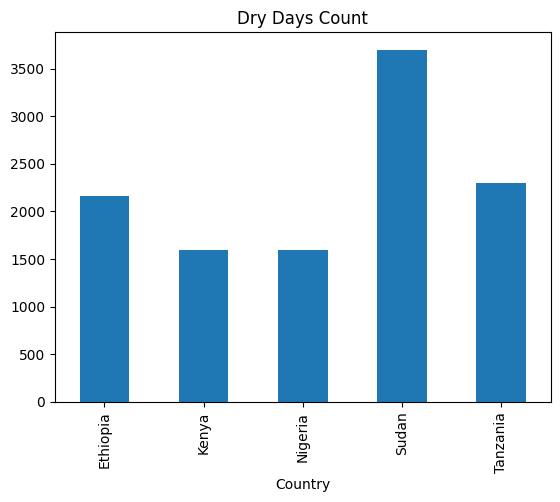

In [9]:
dry = df[df["PRECTOTCORR"] < 1]
dry_counts = dry.groupby("Country").size()

dry_counts.plot(kind="bar")
plt.title("Dry Days Count")
plt.show()

### ☀️ Dry Days Count
1. **Sudan** leads with the highest dry day frequency.  
2. **Tanzania & Ethiopia** follow, showing notable dryness compared to Kenya and Nigeria.  
3. **Nigeria** records the lowest dry day count, reflecting wetter conditions.  
4. Clear gradient: arid Sudan vs. relatively humid Nigeria.

In [10]:
df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,4.213914,1.84,7.266742
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


# 🌍 Final Climate Insights (2015–2026)

The comparative climate analysis across Ethiopia, Kenya, Nigeria, Sudan, and Tanzania reveals distinct stress patterns that highlight both shared regional challenges and country‑specific vulnerabilities.

### 1. Fastest Warming
Sudan emerges as the fastest warming country, with monthly averages consistently peaking near 35 °C and an extraordinary ~2700 extreme heat days. Nigeria also shows elevated averages, indicating a strong warming trajectory, though without the same frequency of extremes. Together, these trends underscore how warming is unevenly distributed, with Sudan at the epicenter of heat stress.

### 2. Most Unstable Rainfall
Tanzania demonstrates the most unstable rainfall regime, with the highest variability (std ≈ 8.0) and wide precipitation spreads. This irregularity suggests unpredictable wet seasons and heightened risk for agriculture and water management. Kenya and Nigeria show moderate variability, while Sudan’s low mean and median confirm its arid baseline rather than instability. Ethiopia’s rainfall profile is uneven, with moderate averages but significant variability, complicating planning despite cooler temperatures.

### 3. Extreme Events
Extreme events highlight divergent vulnerabilities. Sudan dominates in extreme heat days, reinforcing its acute exposure to prolonged heat stress. Ethiopia, while cooler, experiences frequent dry periods, reflecting a different form of climate stress — scarcity of rainfall rather than excess heat. These contrasts show how climate risks manifest differently: heat extremes in Sudan, rainfall instability in Tanzania, and uneven precipitation in Ethiopia.

### 4. Ethiopia’s Position
Ethiopia occupies a middle ground. Its cooler averages (15–20 °C) provide some resilience against heat extremes, but rainfall variability remains a significant challenge. The combination of moderate warming and uneven precipitation makes Ethiopia vulnerable to agricultural disruption and water insecurity, even without the same level of heat stress as Sudan.

### 5. Priority Funding
From a policy perspective, Sudan should be prioritized for climate funding and adaptation support. Its combination of extreme heat frequency, highest dry day counts (~3700), and overall climate stress indicators make it the most vulnerable. Ethiopia and Tanzania also require targeted interventions to manage rainfall variability, while Nigeria’s warming trend calls for resilience planning. Kenya, with moderate variability, sits in a middle zone but still benefits from proactive adaptation.

---

## 📌 Synthesis
- **Sudan**: Fastest warming, most extreme heat, highest dry days → **top priority for funding**.  
- **Tanzania**: Most unstable rainfall → **priority for water/agriculture resilience**.  
- **Ethiopia**: Cooler but uneven rainfall → **support for variability management**.  
- **Nigeria**: Strong warming trend → **monitoring and resilience planning**.  
- **Kenya**: Moderate variability → **balanced but still vulnerable**.

**Final Insight:** Sudan is the epicenter of climate stress, Tanzania leads in rainfall instability, Ethiopia balances cooler temperatures with uneven precipitation, and Nigeria shows strong warming. Funding strategies should focus first on Sudan, while tailoring support for rainfall management in Ethiopia and Tanzania, and monitoring Nigeria’s warming trajectory.
